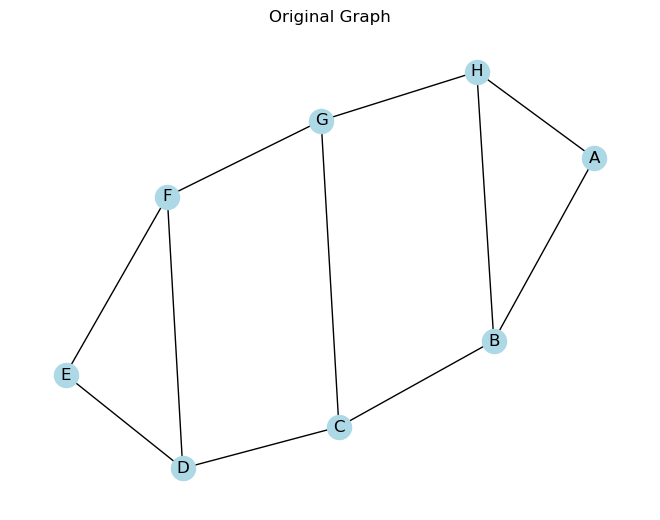

Community 1: ['A', 'B', 'H']
Community 2: ['D', 'F', 'C', 'G', 'E']


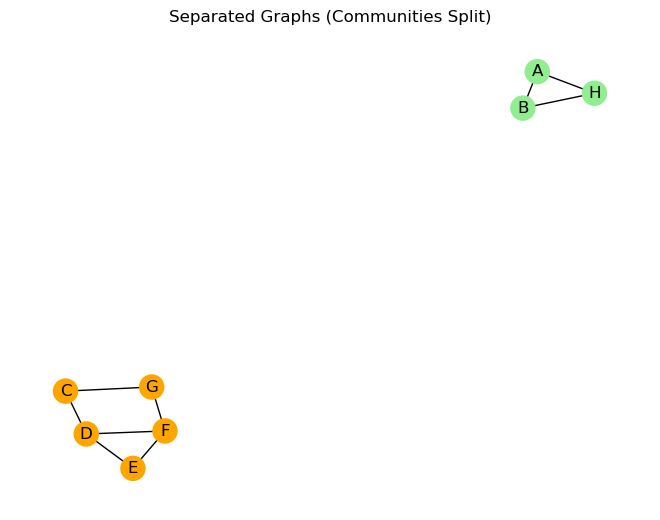

In [1]:
#works in older versions as well except if the community module is not available in the version of networkx you are using. In that case, you can use the community package instead.

import matplotlib.pyplot as plt
import networkx as nx

# 1. Create the Graph
G = nx.Graph()
G.add_edges_from(
    [
        ("A", "B"), ("B", "C"), ("C", "D"),
        ("D", "E"), ("E", "F"), ("F", "G"),
        ("G", "H"), ("H", "A"), ("B", "H"),
        ("C", "G"), ("D", "F"),
    ]
)

# 2. Show Original Graph
nx.draw(G, with_labels=True, node_color="lightblue")
plt.title("Original Graph")
plt.show()

# 3. Use Girvan-Newman to find communities
communities_generator = nx.community.girvan_newman(G)
first_split = next(communities_generator)

comm1 = list(first_split[0])
comm2 = list(first_split[1])

print("Community 1:", comm1)
print("Community 2:", comm2)

# 4. Create a copy and remove edges between the two communities to separate them
G_split = G.copy()
for u, v in G.edges():
    # If the two nodes of an edge belong to different communities, delete it
    if (u in comm1 and v in comm2) or (u in comm2 and v in comm1):
        G_split.remove_edge(u, v)

# 5. Show Separated Graphs
# Assign different colors to the two distinct communities
node_colors = []
for node in G_split.nodes():
    if node in comm1:
        node_colors.append("lightgreen")
    else:
        node_colors.append("orange")

nx.draw(G_split, with_labels=True, node_color=node_colors)
plt.title("Separated Graphs (Communities Split)")
plt.show()

Community 1: ['A', 'B', 'H']
Community 2: ['D', 'F', 'C', 'G', 'E']


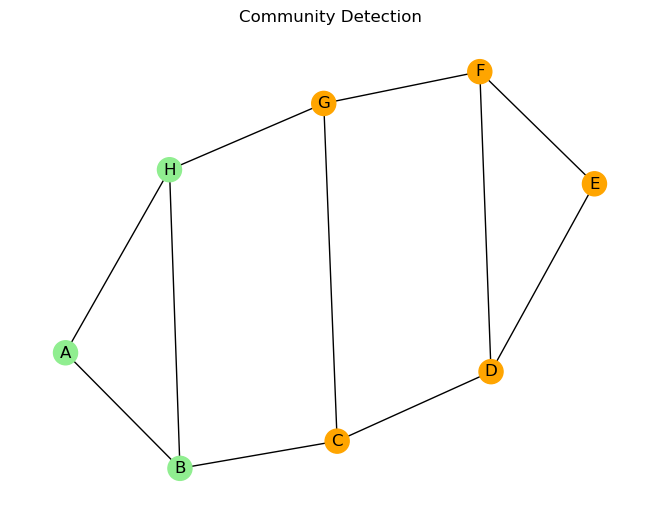

In [2]:
##compatible in older versions

import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import girvan_newman

G = nx.Graph([
    ("A","B"),("B","C"),("C","D"),("D","E"),
    ("E","F"),("F","G"),("G","H"),("H","A"),
    ("B","H"),("C","G"),("D","F")
])

comm1, comm2 = next(girvan_newman(G))

print("Community 1:", list(comm1))
print("Community 2:", list(comm2))

colors = ["lightgreen" if n in comm1 else "orange"
          for n in G.nodes()]

nx.draw(G, with_labels=True, node_color=colors)
plt.title("Community Detection")
plt.show()